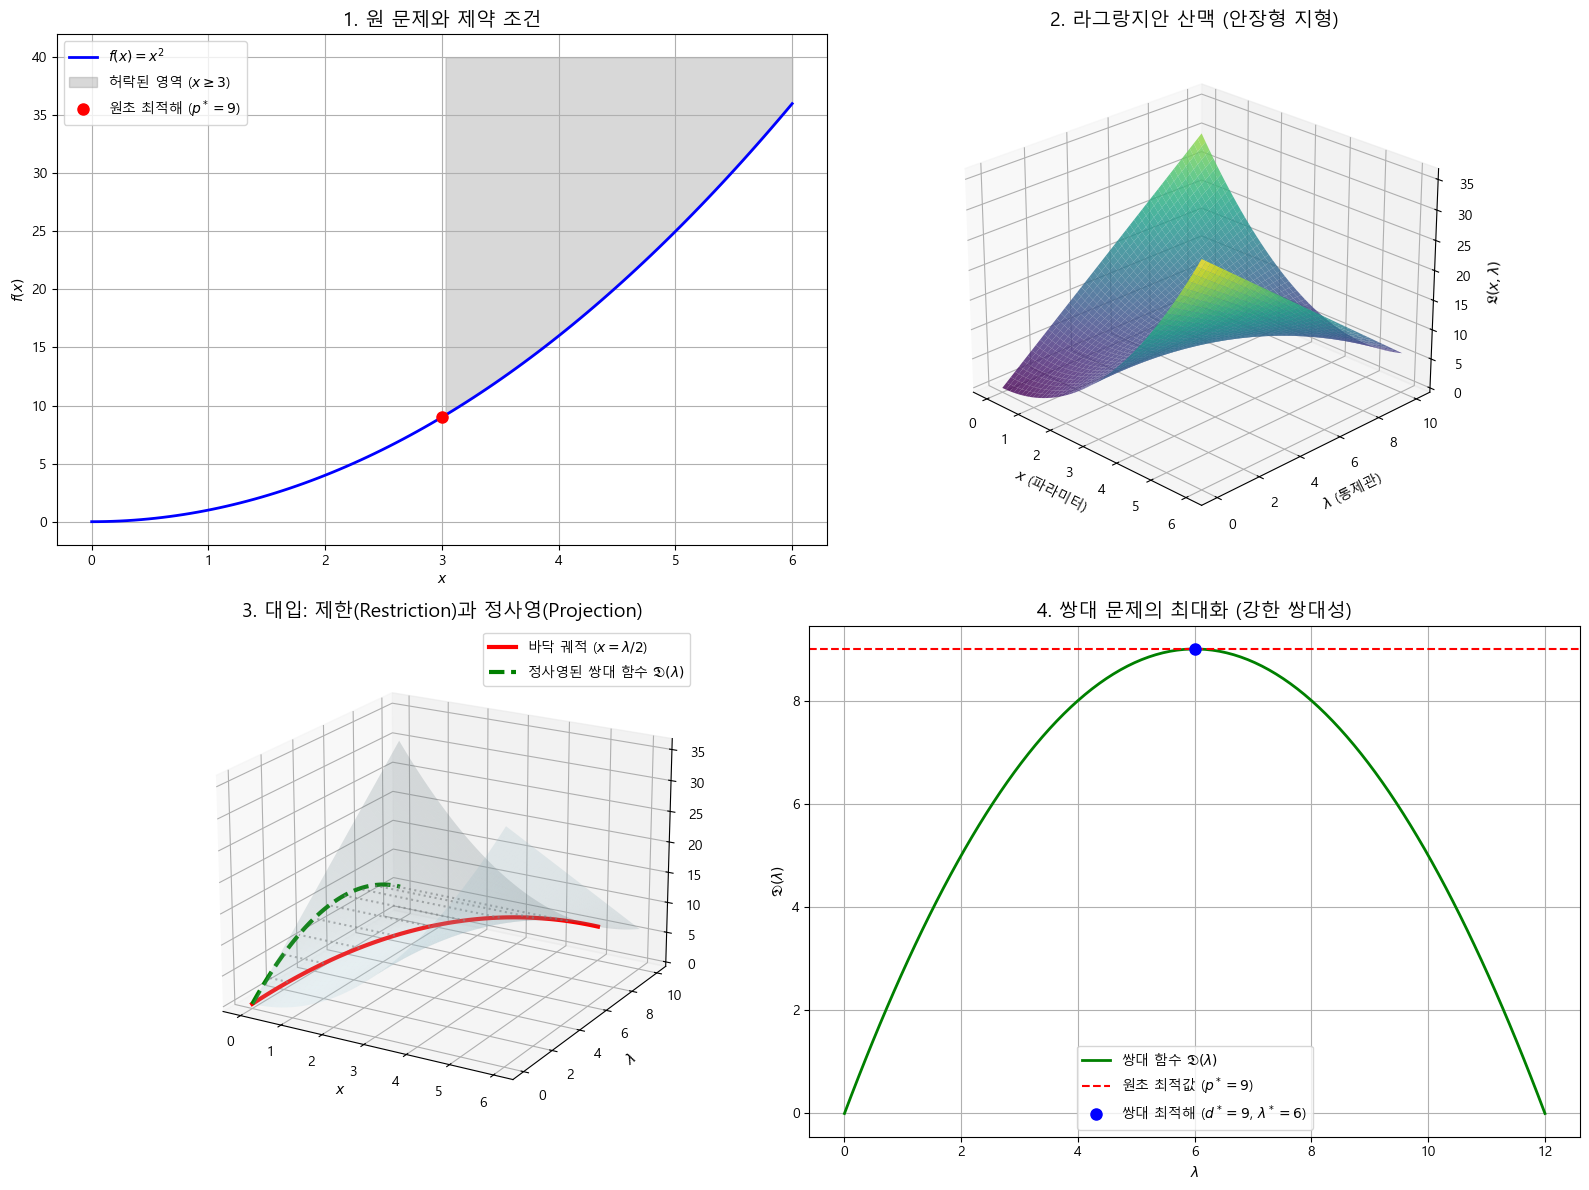

In [2]:
'''
이 코드는 앞서 논의한 1차원 비선형 최적화 문제(f(x)=x^2, x>=3)를 
라그랑주 쌍대성을 통해 해결하는 4가지 핵심 단계를 시각화하는 스크립트입니다.
이전 대화에서 도출한 '비스듬한 평면으로의 제한'과 '벽면으로의 정사영'이라는 
기하학적 통찰을 3D 그래프(subplot 3)로 완벽하게 구현하여 추가했습니다.
'''

import numpy as np
import matplotlib.pyplot as plt

# 폰트 설정 (운영체제에 맞게 수정 필요: Windows='Malgun Gothic', Mac='AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(16, 12))

# ==========================================
# 1. 초기 원 문제와 제약 조건 (2D)
# ==========================================
ax1 = fig.add_subplot(221)
x_val = np.linspace(0, 6, 100)
f_x = x_val**2

ax1.plot(x_val, f_x, 'b-', label='$f(x) = x^2$', linewidth=2)
# 제약 조건 영역 색칠
ax1.fill_between(x_val, f_x, 40, where=(x_val >= 3), color='gray', alpha=0.3, label='허락된 영역 ($x \geq 3$)')
# 정답 마커
ax1.plot(3, 9, 'ro', markersize=8, label='원초 최적해 ($p^*=9$)')

ax1.set_title('1. 원 문제와 제약 조건', fontsize=14)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$f(x)$')
ax1.legend()
ax1.grid(True)

# ==========================================
# 2. 라그랑지안 함수 (3D)
# ==========================================
ax2 = fig.add_subplot(222, projection='3d')
x_grid = np.linspace(0, 6, 50)
l_grid = np.linspace(0, 10, 50)
X, L = np.meshgrid(x_grid, l_grid)
# 라그랑지안 계산식
Z_L = X**2 + L * (3 - X)

ax2.plot_surface(X, L, Z_L, cmap='viridis', alpha=0.8, edgecolor='none')
ax2.view_init(elev=25, azim=-45)

ax2.set_title('2. 라그랑지안 산맥 (안장형 지형)', fontsize=14)
ax2.set_xlabel('$x$ (파라미터)')
ax2.set_ylabel('$\lambda$ (통제관)')
ax2.set_zlabel('$\mathfrak{L}(x, \lambda)$')

# ==========================================
# 3. x = lambda/2 대입의 기하학적 의미 (3D)
# ==========================================
ax3 = fig.add_subplot(223, projection='3d')
# 반투명한 전체 지형
ax3.plot_surface(X, L, Z_L, color='lightblue', alpha=0.2, edgecolor='none')

# 골짜기 바닥의 3차원 궤적 (Restriction)
l_line = np.linspace(0, 10, 100)
x_line = l_line / 2
z_line = x_line**2 + l_line * (3 - x_line)
ax3.plot(x_line, l_line, z_line, 'r-', linewidth=3, label='바닥 궤적 ($x=\lambda/2$)')

# 람다-함숫값 평면으로의 정사영 (Projection)
# 정사영을 위해 x좌표를 0으로 고정
x_proj = np.zeros_like(l_line)
ax3.plot(x_proj, l_line, z_line, 'g--', linewidth=3, label='정사영된 쌍대 함수 $\mathfrak{D}(\lambda)$')

# 정사영 빛(점선) 연결
for i in range(0, len(l_line), 10):
    ax3.plot([x_line[i], 0], [l_line[i], l_line[i]], [z_line[i], z_line[i]], color='gray', linestyle=':', alpha=0.6)

ax3.view_init(elev=20, azim=-60)
ax3.set_title('3. 대입: 제한(Restriction)과 정사영(Projection)', fontsize=14)
ax3.set_xlabel('$x$')
ax3.set_ylabel('$\lambda$')
ax3.legend()

# ==========================================
# 4. 원초문제와 쌍대문제 비교 (2D)
# ==========================================
ax4 = fig.add_subplot(224)
l_val = np.linspace(0, 12, 100)
# 쌍대 함수 수식
d_l = 3 * l_val - (l_val**2) / 4

ax4.plot(l_val, d_l, 'g-', label='쌍대 함수 $\mathfrak{D}(\lambda)$', linewidth=2)
# 원초 최적값 하한선
ax4.axhline(y=9, color='r', linestyle='--', label='원초 최적값 ($p^*=9$)')
# 쌍대 최적해 마커
ax4.plot(6, 9, 'bo', markersize=8, label='쌍대 최적해 ($d^*=9$, $\lambda^*=6$)')

ax4.set_title('4. 쌍대 문제의 최대화 (강한 쌍대성)', fontsize=14)
ax4.set_xlabel('$\lambda$')
ax4.set_ylabel('$\mathfrak{D}(\lambda)$')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

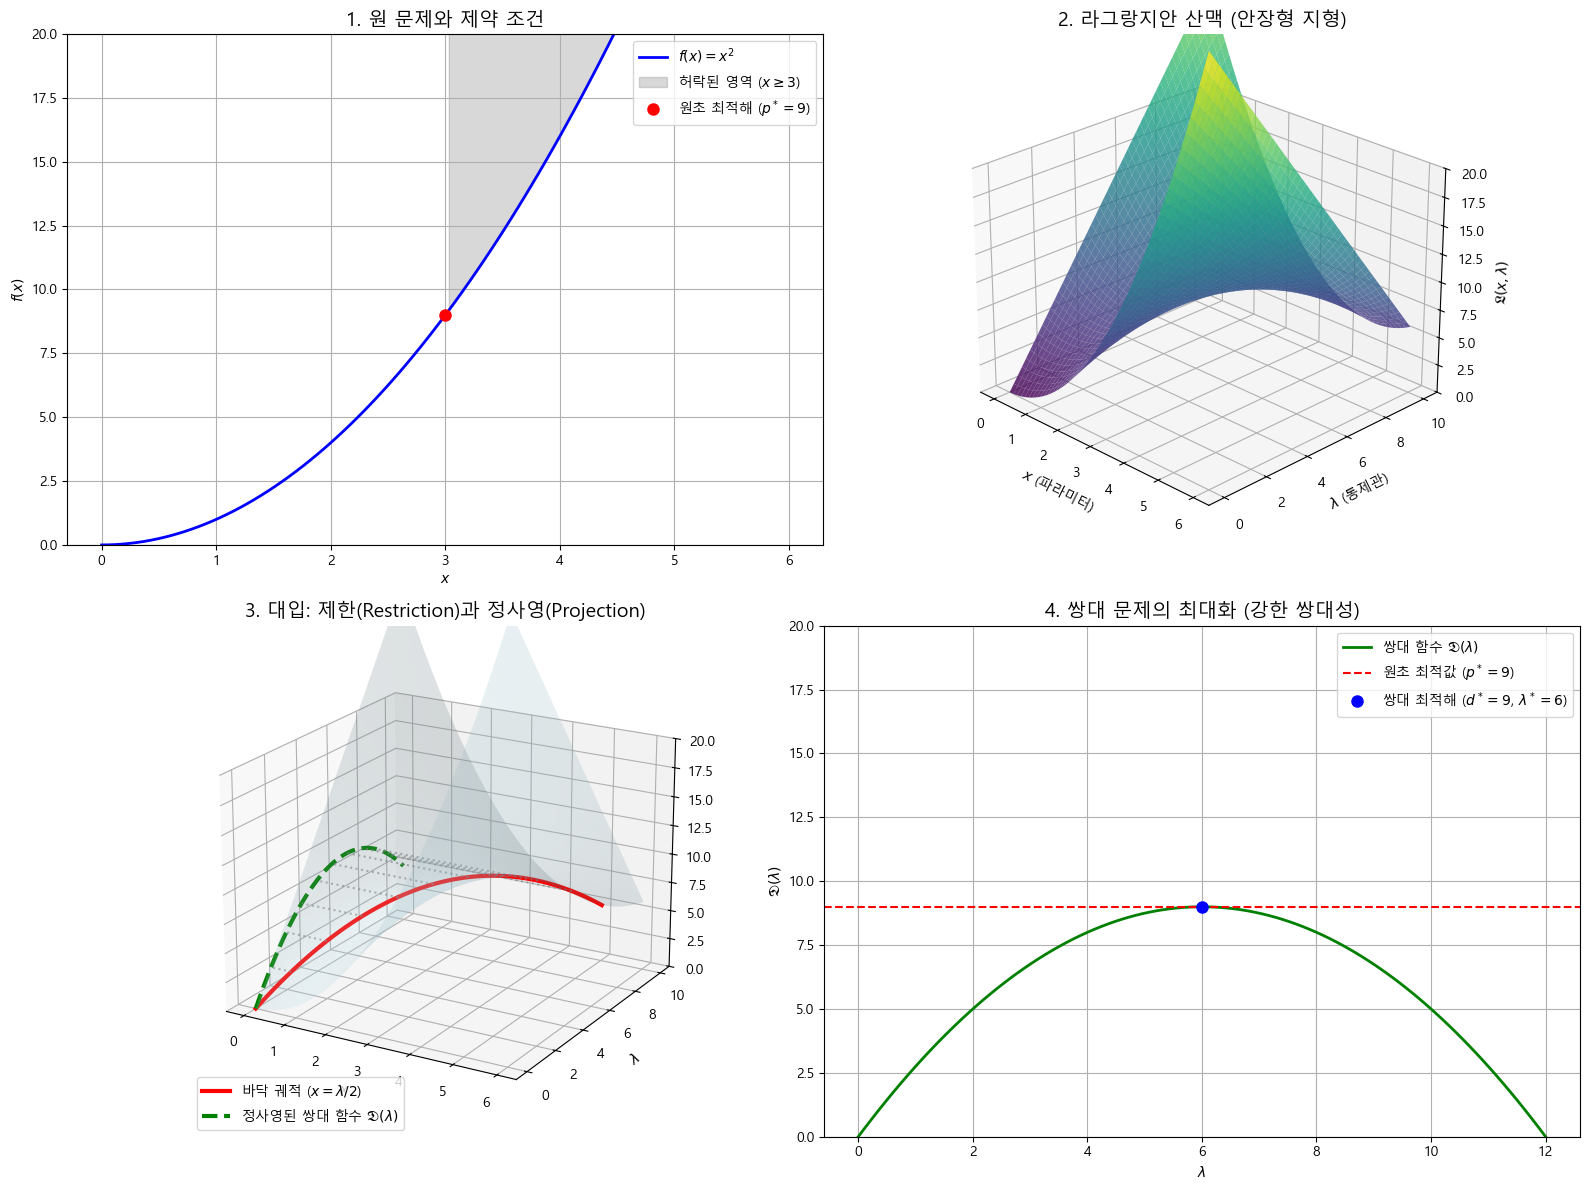

In [3]:
'''
이 코드는 앞서 논의한 1차원 비선형 최적화 문제(f(x)=x^2, x>=3)를 
라그랑주 쌍대성을 통해 해결하는 4가지 핵심 단계를 시각화하는 스크립트입니다.
모든 그래프의 높이(y축, z축) 범위를 0~20으로 통일하여(set_ylim, set_zlim)
높이 변화와 최적값(9)을 직관적으로 비교할 수 있도록 수정되었습니다.
'''

import numpy as np
import matplotlib.pyplot as plt

# 폰트 설정 (운영체제에 맞게 수정 필요: Windows='Malgun Gothic', Mac='AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(16, 12))

# ==========================================
# 1. 초기 원 문제와 제약 조건 (2D)
# ==========================================
ax1 = fig.add_subplot(221)
x_val = np.linspace(0, 6, 100)
f_x = x_val**2

ax1.plot(x_val, f_x, 'b-', label='$f(x) = x^2$', linewidth=2)
# 제약 조건 영역 색칠 (축 범위에 맞춰 높이를 20으로 설정)
ax1.fill_between(x_val, f_x, 20, where=(x_val >= 3), color='gray', alpha=0.3, label='허락된 영역 ($x \geq 3$)')
# 정답 마커
ax1.plot(3, 9, 'ro', markersize=8, label='원초 최적해 ($p^*=9$)')

ax1.set_title('1. 원 문제와 제약 조건', fontsize=14)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$f(x)$')
# [수정] y축 범위 통일
ax1.set_ylim(0, 20)
ax1.legend()
ax1.grid(True)

# ==========================================
# 2. 라그랑지안 함수 (3D)
# ==========================================
ax2 = fig.add_subplot(222, projection='3d')
x_grid = np.linspace(0, 6, 50)
l_grid = np.linspace(0, 10, 50)
X, L = np.meshgrid(x_grid, l_grid)
# 라그랑지안 계산식
Z_L = X**2 + L * (3 - X)

ax2.plot_surface(X, L, Z_L, cmap='viridis', alpha=0.8, edgecolor='none')
ax2.view_init(elev=25, azim=-45)

ax2.set_title('2. 라그랑지안 산맥 (안장형 지형)', fontsize=14)
ax2.set_xlabel('$x$ (파라미터)')
ax2.set_ylabel('$\lambda$ (통제관)')
ax2.set_zlabel('$\mathfrak{L}(x, \lambda)$')
# [수정] z축 범위 통일
ax2.set_zlim(0, 20)

# ==========================================
# 3. x = lambda/2 대입의 기하학적 의미 (3D)
# ==========================================
ax3 = fig.add_subplot(223, projection='3d')
# 반투명한 전체 지형
ax3.plot_surface(X, L, Z_L, color='lightblue', alpha=0.2, edgecolor='none')

# 골짜기 바닥의 3차원 궤적 (Restriction)
l_line = np.linspace(0, 10, 100)
x_line = l_line / 2
z_line = x_line**2 + l_line * (3 - x_line)
ax3.plot(x_line, l_line, z_line, 'r-', linewidth=3, label='바닥 궤적 ($x=\lambda/2$)')

# 람다-함숫값 평면으로의 정사영 (Projection)
x_proj = np.zeros_like(l_line)
ax3.plot(x_proj, l_line, z_line, 'g--', linewidth=3, label='정사영된 쌍대 함수 $\mathfrak{D}(\lambda)$')

# 정사영 빛(점선) 연결
for i in range(0, len(l_line), 10):
    ax3.plot([x_line[i], 0], [l_line[i], l_line[i]], [z_line[i], z_line[i]], color='gray', linestyle=':', alpha=0.6)

ax3.view_init(elev=20, azim=-60)
ax3.set_title('3. 대입: 제한(Restriction)과 정사영(Projection)', fontsize=14)
ax3.set_xlabel('$x$')
ax3.set_ylabel('$\lambda$')
# [수정] z축 범위 통일
ax3.set_zlim(0, 20)
ax3.legend()

# ==========================================
# 4. 원초문제와 쌍대문제 비교 (2D)
# ==========================================
ax4 = fig.add_subplot(224)
l_val = np.linspace(0, 12, 100)
# 쌍대 함수 수식
d_l = 3 * l_val - (l_val**2) / 4

ax4.plot(l_val, d_l, 'g-', label='쌍대 함수 $\mathfrak{D}(\lambda)$', linewidth=2)
# 원초 최적값 하한선
ax4.axhline(y=9, color='r', linestyle='--', label='원초 최적값 ($p^*=9$)')
# 쌍대 최적해 마커
ax4.plot(6, 9, 'bo', markersize=8, label='쌍대 최적해 ($d^*=9$, $\lambda^*=6$)')

ax4.set_title('4. 쌍대 문제의 최대화 (강한 쌍대성)', fontsize=14)
ax4.set_xlabel('$\lambda$')
ax4.set_ylabel('$\mathfrak{D}(\lambda)$')
# [수정] y축 범위 통일
ax4.set_ylim(0, 20)
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()